## Recursive Feature Elimination (RFE)

When working with high-dimensional datasets, many features can be redundant, noisy, or highly correlated. This can lead to overfitting, longer training times, and reduced model interpretability.

Recursive Feature Elimination (RFE) is a wrapper-type feature selection algorithm designed to systematically solve this problem.

The algorithm evaluates the importance of each feature using model specific coefficients (e.g., feature weights in linear models) or feature importances (e.g., impurity-based scores in trees). The least important feature (or a designated fraction of features) is pruned/removed from the feature set.

#### Import Required Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score)

In [2]:
bc = pd.read_csv('/content/drive/MyDrive/ML datasets/breast_cancer.csv')

In [3]:
bc.shape

(569, 33)

In [4]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
# removing empty columns
bc = bc.drop("Unnamed: 32", axis = 1)

In [6]:
bc.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
round(bc.drop("id", axis = 1).describe(), 2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [8]:
# target and features defining
x = bc.drop(["id", "diagnosis"], axis = 1)
y = bc["diagnosis"]

# training testing set splitting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 524)

#### Random Forest Model

In [9]:
# initializing random forest model
rf = RandomForestClassifier(random_state = 524)

# evaluating feature importance recursively across 5 fold cross validation
rf_rfecv = RFECV(estimator = rf, step = 1, cv = 5, scoring = 'accuracy', min_features_to_select = 5)

# fit on training set
rf_rfecv.fit(x_train, y_train)

print(f"optimal number of features: {rf_rfecv.n_features_}")

# extracting selected features
rf_selected_features = x_train.columns[rf_rfecv.support_]
print(f"selected features: {rf_selected_features}")

optimal number of features: 18
selected features: Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'radius_se', 'area_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object')


In [10]:
# predicting and model evaluation
rf_y_pred = rf_rfecv.predict(x_test)
print(round(accuracy_score(rf_y_pred, y_test), 2))
print(classification_report(rf_y_pred, y_test))

0.98
              precision    recall  f1-score   support

           B       0.99      0.99      0.99        77
           M       0.97      0.97      0.97        37

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



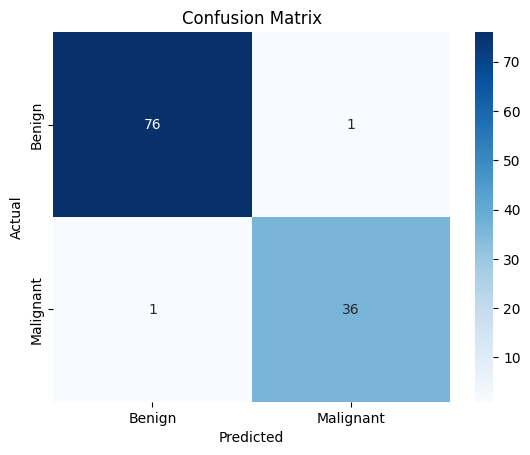

In [11]:
# confusion matrix
cm = confusion_matrix(y_test, rf_y_pred)
sns.heatmap(cm, annot = True, cmap = 'Blues', fmt = 'd')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Benign', 'Malignant'])
plt.yticks([0.5, 1.5], ['Benign', 'Malignant'])
plt.show()

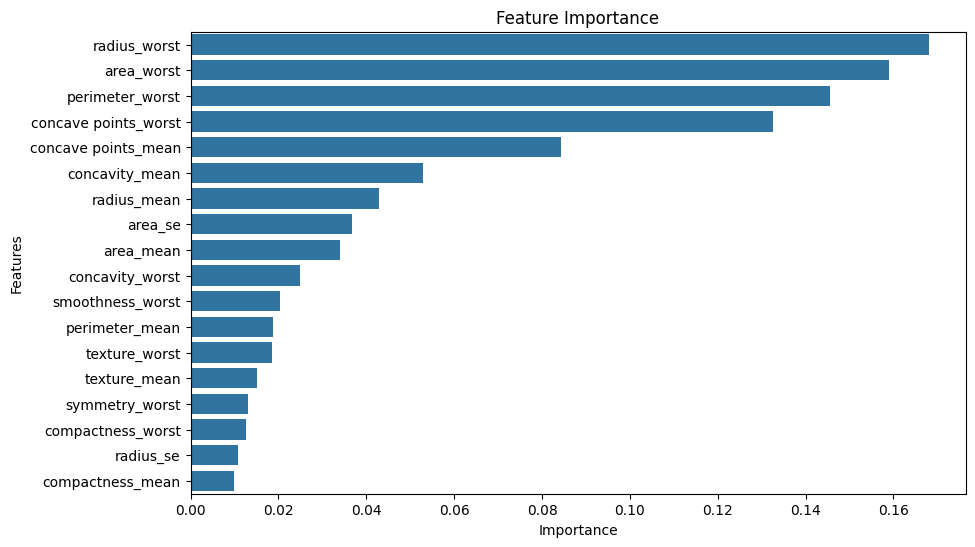

In [12]:
# feature importance plot
rf_importances = rf_rfecv.estimator_.feature_importances_
rf_feature_importance_series = pd.Series(rf_importances, index=rf_selected_features)
rf_sorted_features = rf_feature_importance_series.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_sorted_features.values, y=rf_sorted_features.index)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

#### Gradient Boost model

In [13]:
# initializing xgb model
xgb = GradientBoostingClassifier(random_state = 524)

# evaluating feature importance recursively across 5 fold cross validation
xgb_rfecv = RFECV(estimator = xgb, step = 1, cv = 5, scoring = 'accuracy', min_features_to_select = 5)

# fit on training set
xgb_rfecv.fit(x_train, y_train)

print(f"optimal number of features: {xgb_rfecv.n_features_}")

# extracting selected features
xgb_selected_features = x_train.columns[xgb_rfecv.support_]
print(f"selected features: {xgb_selected_features}")

optimal number of features: 16
selected features: Index(['texture_mean', 'area_mean', 'compactness_mean', 'concave points_mean',
       'radius_se', 'texture_se', 'area_se', 'compactness_se',
       'concave points_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
       'area_worst', 'smoothness_worst', 'concavity_worst',
       'concave points_worst'],
      dtype='object')


In [14]:
# predicting and model evaluation
xgb_y_pred = xgb_rfecv.predict(x_test)
print(round(accuracy_score(xgb_y_pred, y_test), 2))
print(classification_report(xgb_y_pred, y_test))

0.97
              precision    recall  f1-score   support

           B       0.99      0.97      0.98        78
           M       0.95      0.97      0.96        36

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



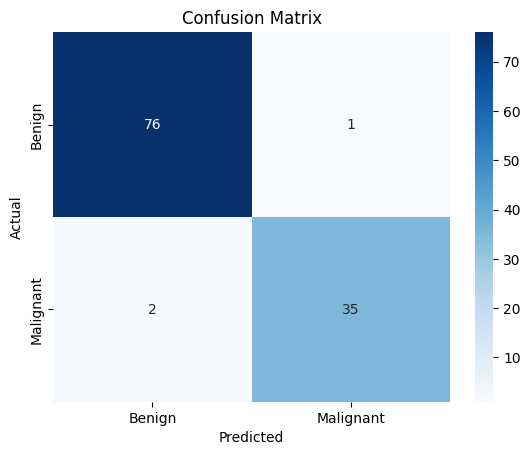

In [15]:
# confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_y_pred)
sns.heatmap(cm_xgb, annot = True, cmap = 'Blues', fmt = 'd')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Benign', 'Malignant'])
plt.yticks([0.5, 1.5], ['Benign', 'Malignant'])
plt.show()

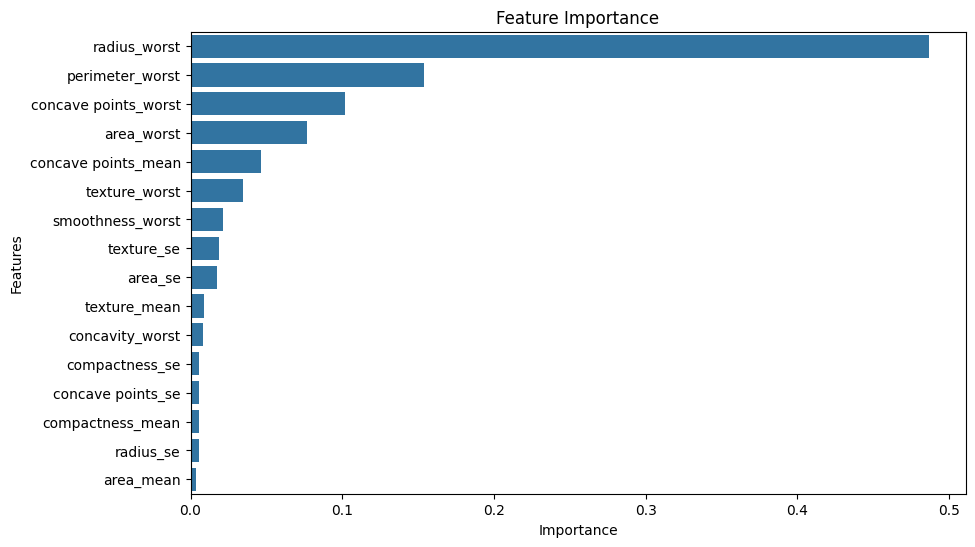

In [16]:
# feature importance plot
xgb_importances = xgb_rfecv.estimator_.feature_importances_
xgb_feature_importance_series = pd.Series(xgb_importances, index=xgb_selected_features)
xgb_sorted_features = xgb_feature_importance_series.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_sorted_features.values, y=xgb_sorted_features.index)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

#### Model Performance Comparison

In [24]:
# comparison table
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boost'],
    'Optimum number of Features': [rf_rfecv.n_features_, xgb_rfecv.n_features_],
    'Accuracy': [accuracy_score(rf_y_pred, y_test), accuracy_score(xgb_y_pred, y_test)],
    'Precision(M)': [precision_score(y_test, rf_y_pred, pos_label= "M"), precision_score(y_test, xgb_y_pred, pos_label= "M")],
    'Recall(M)': [recall_score(y_test, rf_y_pred, pos_label= "M"), recall_score(y_test, xgb_y_pred, pos_label= "M")],
    'F1 Score(M)': [f1_score(y_test, rf_y_pred, pos_label= "M"), f1_score(y_test, xgb_y_pred, pos_label= "M")]
})

comparison

,Model,Optimum number of Features,Accuracy,Precision(M),Recall(M),F1 Score(M)
0,Random Forest,18,0.982456,0.972973,0.972973,0.972973
1,Gradient Boost,16,0.973684,0.972222,0.945946,0.958904


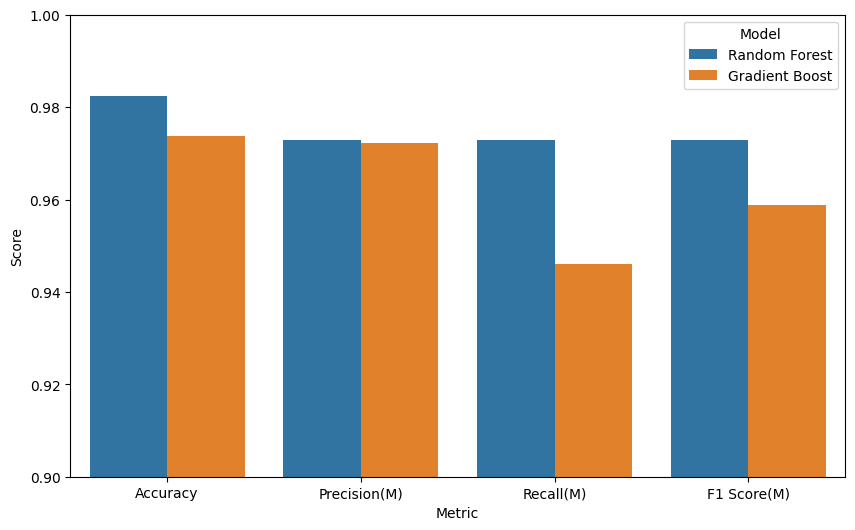

In [30]:
# comparison plot
plotdata = comparison.melt(
    id_vars = "Model",
    value_vars = ["Accuracy", "Precision(M)", "Recall(M)", "F1 Score(M)"],
    var_name = "Metric",
    value_name = "Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(x = 'Metric', y = 'Score', hue = 'Model', data = plotdata)
plt.ylim(0.9, 1.0)
plt.show()